In [1]:
import cellrank as cr
import scanpy as sc
import numpy as np
import h5py
import os
import pandas as pd
from scipy.sparse import csc_matrix

/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/home/andi/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dts_name = "cao_Liver"
path = f"/mnt/d/Starlng_paper/data/{dts_name}.h5ad"
psd_recommendation = pd.read_csv(f"/mnt/d/Starlng_paper/data/{dts_name.lower()}_recommended_pseudotime.csv", index_col=0)
starting_metadata = psd_recommendation["recommended_mtd_name"][0]
starting_group = psd_recommendation["recommended_mtd_group"][0]
grouping_metadata_name = "seurat_clusters" if dts_name != "masld_immune" else "stable_24_clusters"

/tmp/ipykernel_36534/1119108689.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  starting_metadata = psd_recommendation["recommended_mtd_name"][0]
/tmp/ipykernel_36534/1119108689.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  starting_group = psd_recommendation["recommended_mtd_group"][0]


In [3]:
adata = sc.read_h5ad(path)
adata.X = adata.layers["counts"].copy()
adata.obs["total_counts"] = adata.X.sum(axis=1)
adata.layers["counts"] = adata.X.copy()
sc.pp.filter_cells(adata, min_genes = 5)
sc.pp.filter_genes(adata, min_cells = 5)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.layers["log_normalized"] = adata.X.copy()
sc.pp.scale(adata)

/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [4]:
adata

AnnData object with n_obs × n_vars = 11458 × 15773
    obs: 'sample', 'Exon_reads', 'Intron_reads', 'All_reads', 'RT_group', 'Organ', 'Fetus_id', 'Development_day', 'Sex', 'Batch', 'Main_cluster_umap_1', 'Main_cluster_umap_2', 'Main_cluster_name', 'Assay', 'Organ_cell_lineage', 'Experiment_batch', 'nFeature_RNA', 'nCount_RNA', 'percent_mt', 'percent_rp', 'RNA_snn_res.0.8', 'seurat_clusters', 'total_counts', 'n_genes'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'var.features', 'var.features.rank', 'n_cells', 'mean', 'std'
    uns: 'log1p'
    obsm: 'pca', 'umap'
    layers: 'counts', 'data', 'log_normalized'
    obsp: 'nn', 'snn'

In [5]:
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30, random_state = 42, use_rep = "pca")
sc.tl.draw_graph(adata, random_state = 42, init_pos = "umap")

In [6]:
sc.tl.paga(adata, groups=grouping_metadata_name)

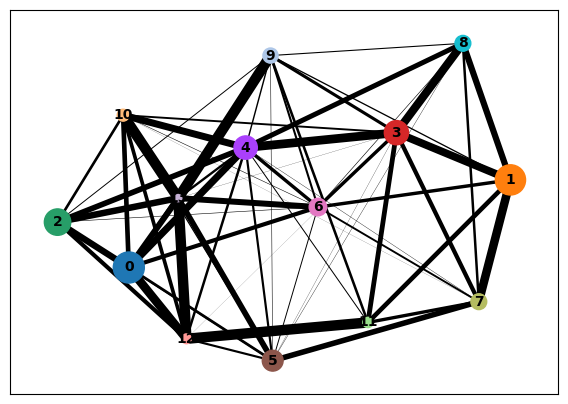

In [7]:

sc.pl.paga(adata)

In [8]:
adata.uns["iroot"] = np.argmin(np.linalg.norm(adata.obsm["umap"] - adata[adata.obs[starting_metadata] == starting_group].obsm["umap"].mean(axis=0), axis=1))
sc.tl.dpt(adata)

In [9]:
pt_kernel = cr.kernels.PseudotimeKernel(adata, time_key="dpt_pseudotime")
pt_kernel.compute_transition_matrix()

INFO     Computing transition matrix based on pseudotime                                                           


  0%|          | 0/11458 [00:00<?, ?cell/s]

100%|██████████| 11458/11458 [00:03<00:00, 3009.21cell/s]


INFO         Finish (4.63s)                                                                                        


PseudotimeKernel[n=11458, dnorm=False, scheme='hard', frac_to_keep=0.3]

In [10]:
pt_es = cr.estimators.GPCCA(pt_kernel)
pt_es.fit(cluster_key = grouping_metadata_name)

INFO     Computing eigendecomposition of the transition matrix                                                     


/tmp/ipykernel_36534/895185879.py:2: DeprecationWarning: `GPCCA.fit()` is deprecated and will be removed in CellRank 3.0. Use `GPCCA.compute_schur()` and `GPCCA.compute_macrostates()` directly.
  pt_es.fit(cluster_key = grouping_metadata_name)


INFO     Adding `adata.uns['eigendecomposition_fwd']`                                                              
                `.eigendecomposition`                                                                              
             Finish (0.65s)                                                                                        
WARNING  Unable to import `petsc4py` or `slepc4py`. Using `method='brandts'`                                       
WARNING  For `method='brandts'`, dense matrix is required. Densifying                                              
INFO     Computing Schur decomposition                                                                             
INFO     Adding `adata.uns['eigendecomposition_fwd']`                                                              
                `.schur_vectors`                                                                                   
                `.schur_matrix`                                         

GPCCA[kernel=PseudotimeKernel[n=11458], initial_states=None, terminal_states=None]

In [11]:
pt_es.set_initial_states({"0": adata.obs_names[adata.obs[starting_metadata] == starting_group]}, cluster_key = starting_metadata, n_cells = 15)
pt_es.predict_terminal_states(allow_overlap=True)
pt_es.compute_fate_probabilities()

INFO     Adding `adata.obs['init_states_fwd']`                                                                     
                `adata.obs['init_states_fwd_probs']`                                                               
                `.initial_states`                                                                                  
                `.initial_states_probabilities`                                                                    
                `.initial_states_memberships                                                                       
             Finish`                                                                                               
INFO     Adding `adata.obs['term_states_fwd']`                                                                     
                `adata.obs['term_states_fwd_probs']`                                                               
                `.terminal_states`                                      

100%|██████████| 6/6 [00:01<00:00,  3.70/s]


INFO     Adding `adata.obsm['lineages_fwd']`                                                                       
                `.fate_probabilities`                                                                              
             Finish (1.71s)                                                                                        


In [12]:
adata.X = adata.layers["log_normalized"].copy()
model = cr.models.GAM(adata, n_knots = 6)

In [13]:
trend_genes = adata.var_names
# get the lowest lineage
lineage_name_term = list(map(str, adata.obs["term_states_fwd"].cat.categories.to_list()))
lineage_name_initial = list(map(str, adata.obs["init_states_fwd"].cat.categories.to_list()))
print(lineage_name_term)
print(lineage_name_initial)
if not lineage_name_term:
    raise ValueError("No terminal lineage names were found in `term_states_fwd`.")

selected_lineage = starting_group if starting_group in lineage_name_term else lineage_name_term[0]

['0', '11', '9', '5', '1', '2']
['Liver_H27058']


In [14]:
cr.pl.cluster_trends(
    adata,
    model=model,
    lineage=selected_lineage,
    genes=trend_genes,
    time_key="dpt_pseudotime",
    n_jobs=8,
    random_state=0,
    # pca_kwargs={"n_comps": 1, "svd_solver": "auto", "random_state": 0},
    # clustering_kwargs={"resolution": 0.4, "random_state": 0},
    # neighbors_kwargs={"n_neighbors": 2, "random_state": 42},
    recompute=True,
)

INFO     Computing trends using 8 core(s)                                                                          


  0%|          | 0/15773 [00:00<?, ?gene/s]/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packa

KeyboardInterrupt: 